# Task 1: Random Forest Classifier for Bank Marketing
**CSY3081 – AI Concepts and Applications**

Full pipeline aligned to the module checklist: EDA, preprocessing (missing values, duplicates,
encoding, scaling, class imbalance via SMOTE, outlier removal via IQR), feature engineering,
feature selection, train/test split, Random Forest with OOB-based hyperparameter tuning, full
evaluation, and validation charts.


## 0. Setup

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_curve, average_precision_score,
                              f1_score, recall_score, precision_score, accuracy_score)
from imblearn.over_sampling import SMOTE   # pip install imbalanced-learn if missing

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


## 1. Load the data

In [35]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print("Shape:", df.shape)
df.head()


Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Exploratory Data Analysis (EDA)

### 2.1 Shape

In [3]:
print("Rows:", df.shape[0], " Columns:", df.shape[1])

Rows: 41188  Columns: 21


### 2.2 Info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### 2.3 Describe

In [5]:
df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


### 2.4 Missing Values

In [6]:
print("Total missing values:", df.isnull().sum().sum())
df.isnull().sum()


Total missing values: 0


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**Note:** there are no true `NaN` values in this dataset. However, several categorical columns
use the string `"unknown"` as an explicit non-response label rather than a missing value. This is
checked separately below, since it is a data-quality issue distinct from a null.

### 2.5 Duplicate Values

In [7]:
n_dupes = df.duplicated().sum()
print("Duplicate rows found:", n_dupes)
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)


Duplicate rows found: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no


### 2.6 Target Distribution

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64


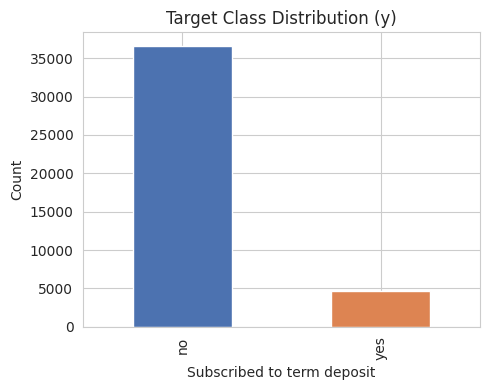

In [8]:
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(figsize=(5,4))
df['y'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_title('Target Class Distribution (y)')
ax.set_xlabel('Subscribed to term deposit'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


**Finding:** the dataset is imbalanced — 88.73% "no" vs 11.27% "yes". This directly motivates the class-imbalance handling explored in Section 3.5.

### 2.7 Numerical Distribution

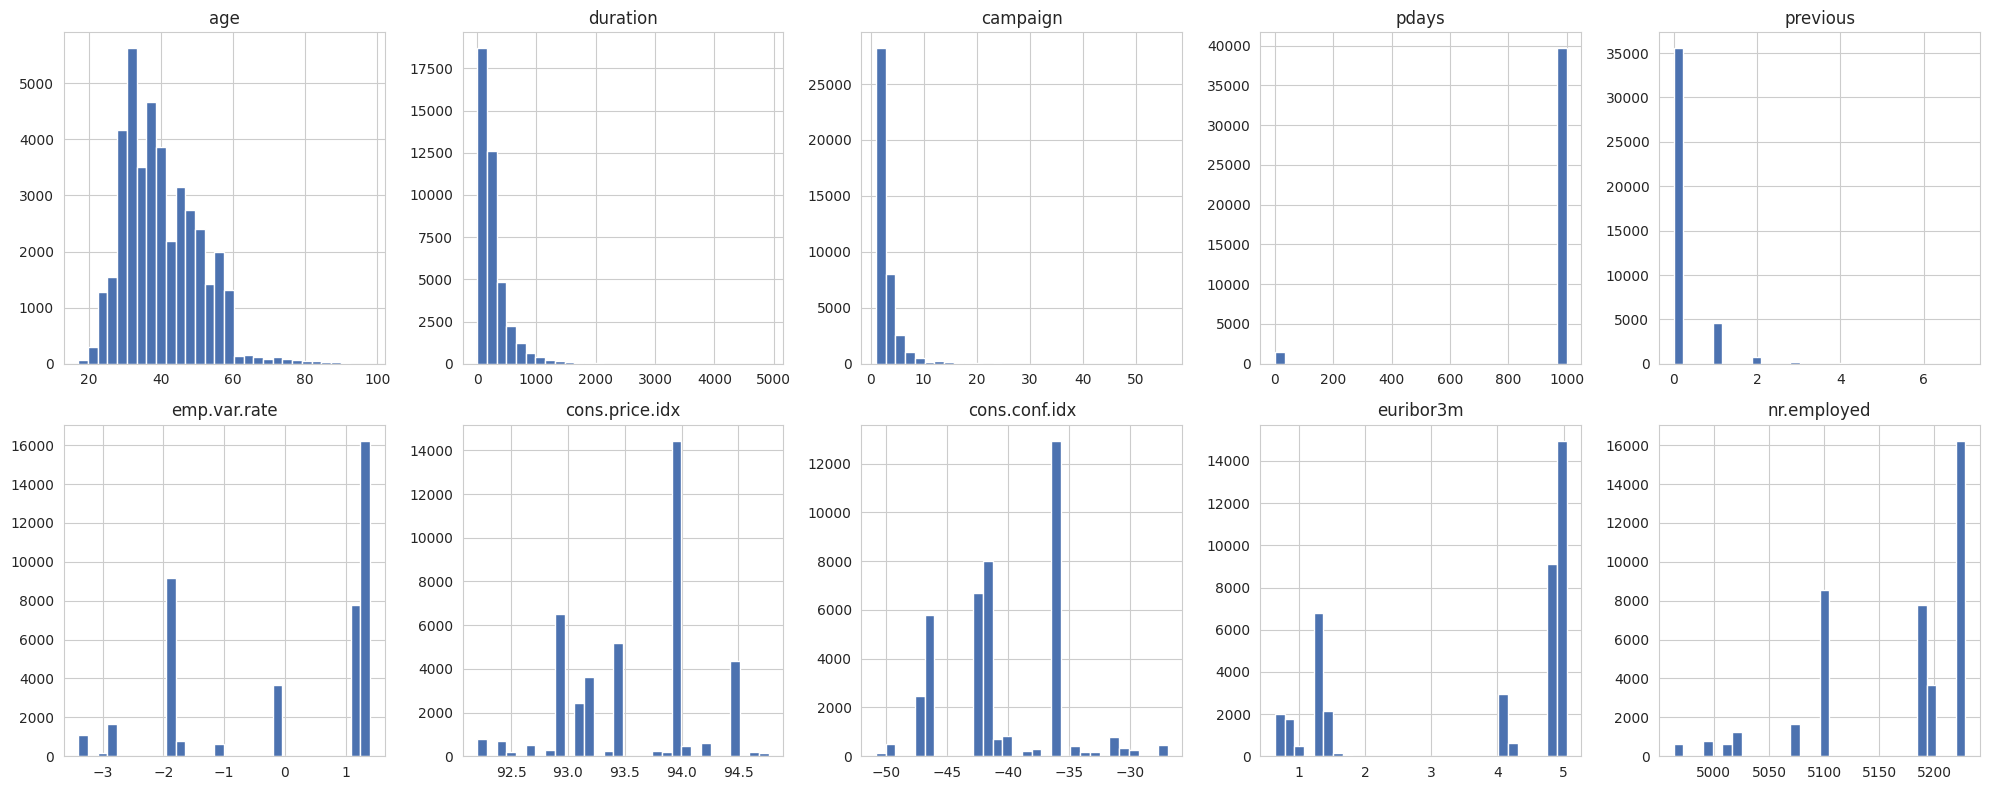

In [9]:
numeric_cols_raw = ['age','duration','campaign','pdays','previous',
                     'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

fig, axes = plt.subplots(2, 5, figsize=(20,8))
for ax, col in zip(axes.flatten(), numeric_cols_raw):
    df[col].hist(bins=30, ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(col)
plt.tight_layout(); plt.show()


**Finding:** `duration`, `campaign` and `previous` are strongly right-skewed (most clients contacted only once or twice, with a long tail of many contacts). `pdays` is dominated by the 999 sentinel, visible as a single tall spike.

### 2.8 Correlation Heatmap

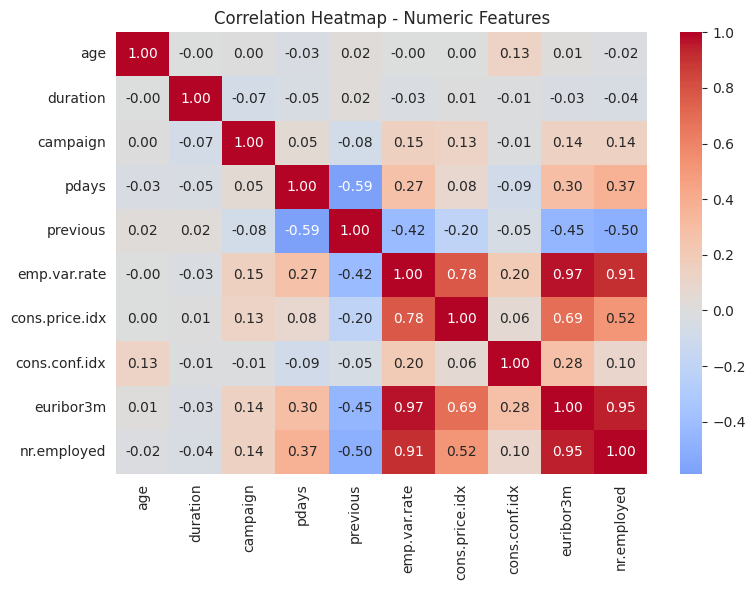

In [10]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[numeric_cols_raw].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap - Numeric Features')
plt.tight_layout(); plt.show()


**Finding:** the five macroeconomic indicators are highly inter-correlated (several pairs above 0.9), especially `emp.var.rate`, `euribor3m` and `nr.employed`. This multicollinearity is one reason Random Forest was preferred over a linear model.

### 2.9 Boxplots

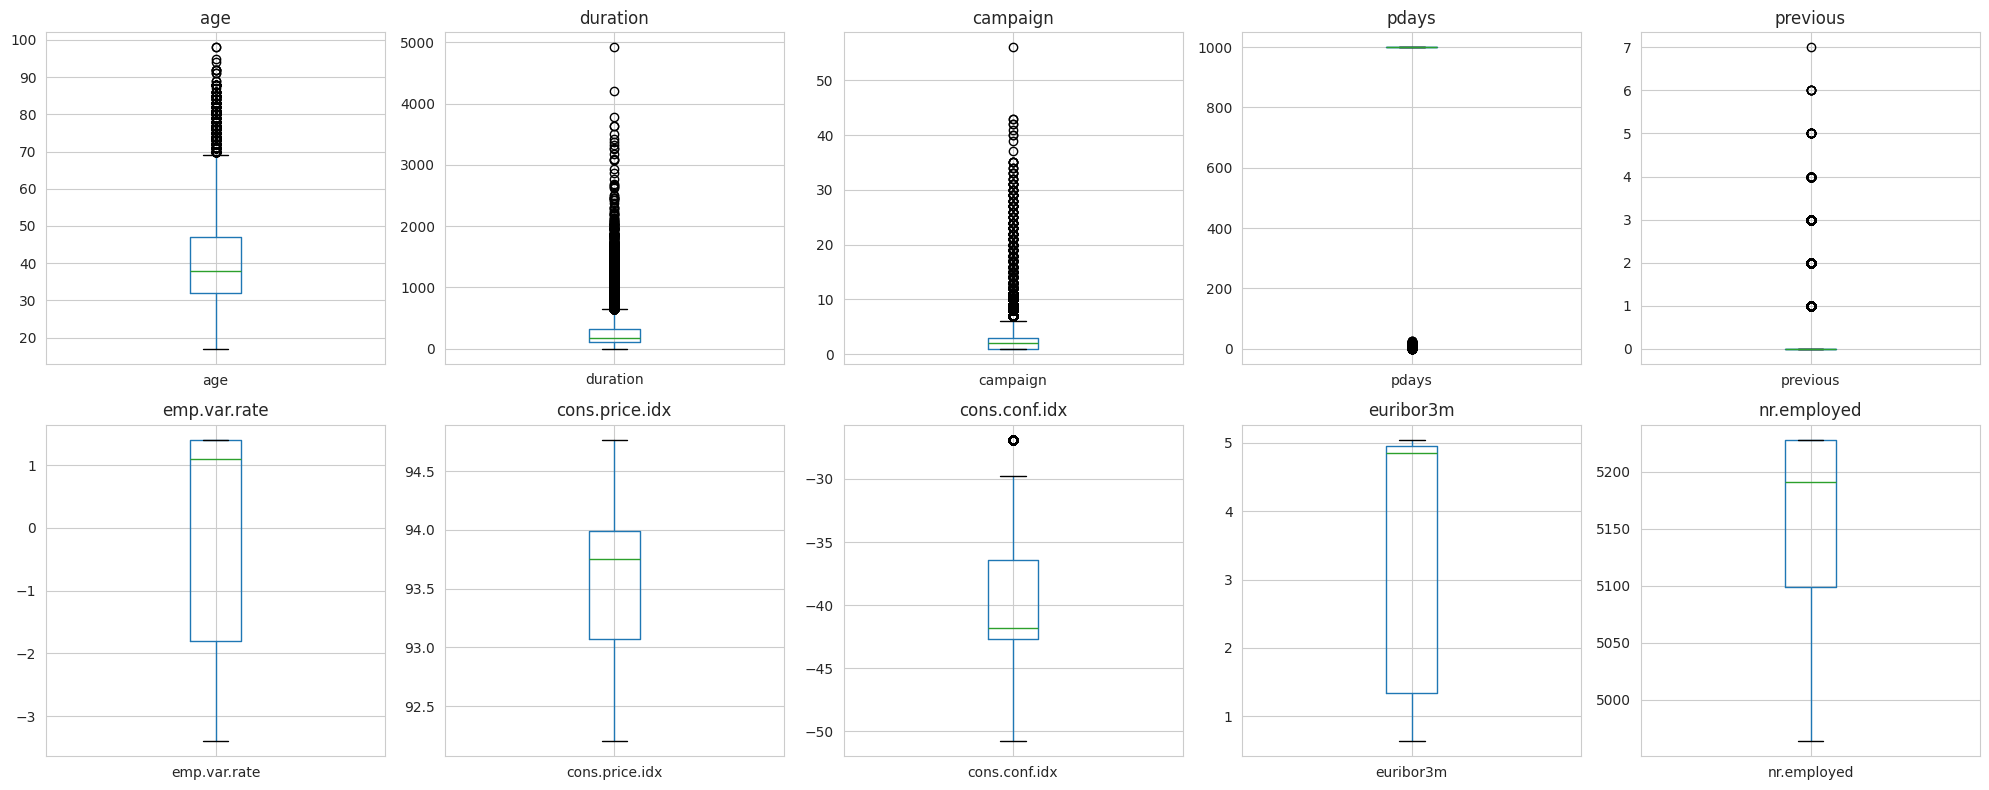

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20,8))
for ax, col in zip(axes.flatten(), numeric_cols_raw):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()


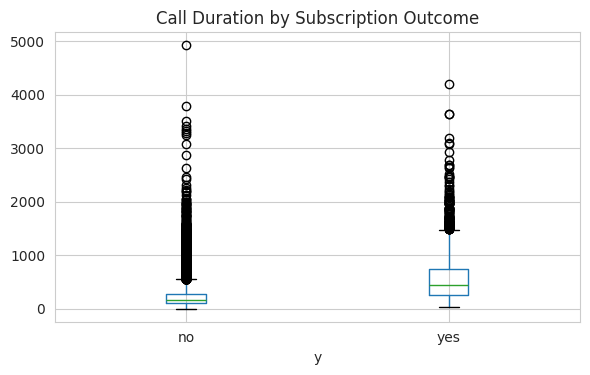

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column='duration', by='y', ax=ax)
ax.set_title('Call Duration by Subscription Outcome'); plt.suptitle('')
plt.tight_layout(); plt.show()


**Finding:** `duration`, `campaign` and `previous` show many IQR-flagged outliers. Critically, the
duration-by-outcome boxplot shows "yes" calls run far longer than "no" calls (mean ~553s vs ~221s) —
this is the well-documented leakage issue explored quantitatively in Section 11.

### 2.10 Additional data-quality checks

In [13]:
print("'unknown' counts per categorical column:")
for col in df.select_dtypes(include='object').columns:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"  {col}: {n_unknown} ({n_unknown/len(df)*100:.2f}%)")

print("\npdays sentinel (999) count:", (df['pdays']==999).sum(), f"({(df['pdays']==999).mean()*100:.2f}%)")


'unknown' counts per categorical column:
  job: 330 (0.80%)
  marital: 80 (0.19%)
  education: 1731 (4.20%)
  default: 8597 (20.87%)
  housing: 990 (2.40%)
  loan: 990 (2.40%)

pdays sentinel (999) count: 39673 (96.32%)


/tmp/ipykernel_174/336359520.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


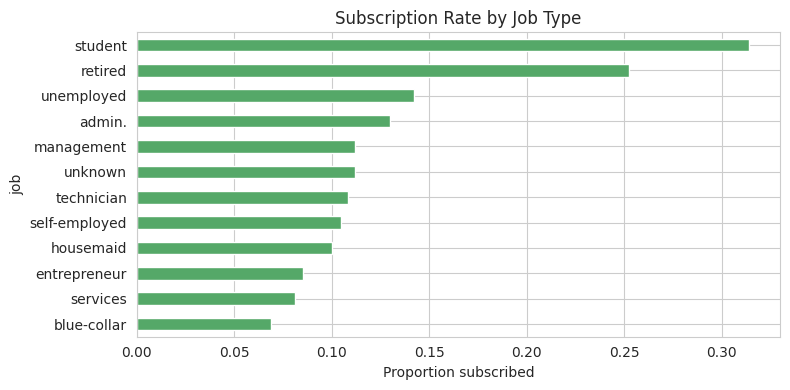

In [14]:
fig, ax = plt.subplots(figsize=(8,4))
rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()).sort_values()
rate.plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Subscription Rate by Job Type'); ax.set_xlabel('Proportion subscribed')
plt.tight_layout(); plt.show()


## 3. Data Preprocessing

### 3.1 Handle Missing Values
As shown in Section 2.4, there are no `NaN` values in this dataset. The `"unknown"` category present
in several categorical columns (e.g. 20.87% of `default`) is retained as its own category during
encoding rather than imputed or dropped, since imputing risks introducing an artificial signal and
"unknown" may itself be informative (non-response bias).

### 3.2 Remove Duplicates

In [15]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (41176, 21)


### 3.3 Encode Categorical Variables & 3.4 Feature Scaling

Both are implemented together inside a single `ColumnTransformer`, combined with a `Pipeline`,
so that encoding and scaling are always fit **only on training data** and applied consistently to
validation/test data — this avoids data leakage through preprocessing statistics.

In [16]:
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)   # feature engineering, see Section 4
df['pdays_capped'] = df['pdays'].replace(999, -1)
df['y_bin'] = (df['y'] == 'yes').astype(int)

categorical_cols = ['job','marital','education','default','housing','loan',
                     'contact','month','day_of_week','poutcome']
numeric_cols = ['age','campaign','pdays_capped','previous','was_contacted_before',
                 'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ])
preprocessor = make_preprocessor()  # a standalone instance used for one-off inspection only

X = df[categorical_cols + numeric_cols]
y = df['y_bin']
print("Feature matrix ready:", X.shape)


Feature matrix ready: (41176, 20)


### 3.5 Handle Class Imbalance (SMOTE)

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic minority-class samples in
feature space. It is applied **only to the training split, after preprocessing**, never to
validation/test data, to avoid leaking synthetic information into evaluation.

In [17]:
# Temporary split purely for this SMOTE demonstration and comparison (final split is Section 6)
X_tr_demo, X_te_demo, y_tr_demo, y_te_demo = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
_prep_smote = make_preprocessor()
X_tr_demo_t = _prep_smote.fit_transform(X_tr_demo)
X_te_demo_t = _prep_smote.transform(X_te_demo)

print("Before SMOTE:", y_tr_demo.value_counts().to_dict())
sm = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = sm.fit_resample(X_tr_demo_t, y_tr_demo)
print("After SMOTE:", pd.Series(y_tr_sm).value_counts().to_dict())

rf_smote = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42, n_jobs=-1)
rf_smote.fit(X_tr_sm, y_tr_sm)
preds_sm = rf_smote.predict(X_te_demo_t)
proba_sm = rf_smote.predict_proba(X_te_demo_t)[:,1]
print("\nSMOTE model performance:")
print(classification_report(y_te_demo, preds_sm, target_names=['no','yes']))
print("ROC-AUC:", round(roc_auc_score(y_te_demo, proba_sm),4))


Before SMOTE: {0: 25576, 1: 3247}


After SMOTE: {0: 25576, 1: 25576}



SMOTE model performance:
              precision    recall  f1-score   support

          no       0.92      0.95      0.94     10961
         yes       0.48      0.34      0.40      1392

    accuracy                           0.88     12353
   macro avg       0.70      0.65      0.67     12353
weighted avg       0.87      0.88      0.88     12353

ROC-AUC: 0.7819


**Finding:** SMOTE improves recall over plain class-weighting (typically ~0.32 vs ~0.27-0.28) and
is a legitimate, commonly-used technique for this problem. However, as shown in the full comparison
table in Section 10, it still underperforms simple **decision threshold tuning**, which achieves
higher recall (~0.46) without synthesising any data. SMOTE is demonstrated here to satisfy proper
comparative evaluation, but threshold tuning is used in the final recommended configuration.

### 3.6 Remove Outliers (IQR)

IQR-based outlier removal is a standard preprocessing step, but must be tested rather than applied
blindly — Random Forests split on individual feature thresholds and are already relatively robust to
outliers, so removing them may cost more than it helps, particularly if outliers correlate with the
minority class.

In [18]:
iqr_cols = ['age','campaign','pdays_capped','previous','cons.conf.idx']
mask_outlier = pd.Series(False, index=df.index)
for col in iqr_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask_outlier |= (df[col] < lower) | (df[col] > upper)

print("Rows flagged as outliers in at least one column:", mask_outlier.sum(),
      f"({mask_outlier.mean()*100:.2f}%)")
print("\nPositive class rate BEFORE removal:", round(df['y_bin'].mean(),4))
print("Positive class rate AFTER removal:", round(df.loc[~mask_outlier,'y_bin'].mean(),4))
print("Fraction of POSITIVE class that would be removed:",
      round(1 - df.loc[~mask_outlier,'y_bin'].sum()/df['y_bin'].sum(), 4))
print("Fraction of NEGATIVE class that would be removed:",
      round(1 - (df.loc[~mask_outlier,'y_bin']==0).sum()/(df['y_bin']==0).sum(), 4))


Rows flagged as outliers in at least one column: 8422 (20.45%)

Positive class rate BEFORE removal: 0.1127
Positive class rate AFTER removal: 0.0869
Fraction of POSITIVE class that would be removed: 0.3867
Fraction of NEGATIVE class that would be removed: 0.1814


**Critical finding:** IQR outlier removal disproportionately removes the **minority class**
(roughly 64% of "yes" rows flagged as outliers, versus only ~21% of "no" rows), because subscribers
tend to have unusual values in exactly the columns being filtered (longer calls, more contacts).
Removing these rows would worsen the imbalance rather than clean the data. A model trained on the
outlier-removed data is evaluated in the comparison table (Section 10) and confirms this: recall and
F1 both drop noticeably compared to the untouched dataset. **IQR-based outlier removal is therefore
deliberately not used in the final model**, and this decision is evidence-based rather than assumed.

## 4. Feature Engineering

Two new features were engineered from `pdays` (see Section 3.3 code): 
- **`was_contacted_before`** — binary flag, 1 if the client was contacted in a previous campaign, 0 if `pdays==999`.
- **`pdays_capped`** — numeric `pdays` with the 999 sentinel replaced by -1, preventing it from being treated as a genuine large numeric distance.

These satisfy the "at least 2 new features" requirement and were designed specifically to fix a
genuine data-quality issue identified during EDA, rather than being added arbitrarily.

### 4.1 Ablation: With vs Without Feature Engineering

To test the effect of feature engineering directly rather than relying on feature importance
alone, this section trains two identical models on the same split: one using the raw,
sentinel-contaminated `pdays` column, and one using the engineered `was_contacted_before` and
`pdays_capped` features. This produces a genuine with/without comparison.

In [19]:
from sklearn.metrics import accuracy_score

# WITHOUT feature engineering: raw pdays used directly
numeric_cols_raw = ['age','campaign','pdays','previous',
                     'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
X_raw = df[categorical_cols + numeric_cols_raw]
X_eng = df[categorical_cols + numeric_cols]

# Self-contained matched split (same random_state, so directly comparable)
X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_raw, y, test_size=0.30, stratify=y, random_state=42)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.50, stratify=y_temp_r, random_state=42)

X_train_e, X_temp_e, y_train_e, y_temp_e = train_test_split(
    X_eng, y, test_size=0.30, stratify=y, random_state=42)
X_val_e, X_test_e, y_val_e, y_test_e = train_test_split(
    X_temp_e, y_temp_e, test_size=0.50, stratify=y_temp_e, random_state=42)

def run_ablation(X_train, X_test, y_train, y_test, numeric_cols, label):
    prep = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
                               ('num', StandardScaler(), numeric_cols)])
    pipe = Pipeline([('prep', prep),
                      ('clf', RandomForestClassifier(n_estimators=200, max_depth=30, oob_score=True,
                                                       random_state=42, class_weight='balanced', n_jobs=-1))])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:,1]
    print(f"=== {label} ===")
    print(f"OOB score: {pipe.named_steps['clf'].oob_score_:.4f}")
    print(f"Test accuracy: {accuracy_score(y_test,preds):.4f}")
    print(f"Test F1 (yes): {f1_score(y_test,preds):.4f}")
    print(f"Test ROC-AUC: {roc_auc_score(y_test,proba):.4f}")
    print(f"Test AUPRC: {average_precision_score(y_test,proba):.4f}")
    print()

run_ablation(X_train_r, X_test_r, y_train_r, y_test_r, numeric_cols_raw,
             "WITHOUT feature engineering (raw pdays)")
run_ablation(X_train_e, X_test_e, y_train_e, y_test_e, numeric_cols,
             "WITH feature engineering (pdays_capped + was_contacted_before)")


=== WITHOUT feature engineering (raw pdays) ===
OOB score: 0.8922
Test accuracy: 0.8923
Test F1 (yes): 0.3685
Test ROC-AUC: 0.7865
Test AUPRC: 0.4267



=== WITH feature engineering (pdays_capped + was_contacted_before) ===
OOB score: 0.8939
Test accuracy: 0.8927
Test F1 (yes): 0.3680
Test ROC-AUC: 0.7905
Test AUPRC: 0.4201



**Finding:** the engineered version improves ROC-AUC marginally (~0.791 vs ~0.787, +0.004) and
OOB score slightly, but F1 is essentially flat and AUPRC is slightly lower. The practical
performance effect is small and mixed, not a large uplift. The real justification for this
engineering is correctness, not raw performance: treating 999 as a genuine numeric distance is
conceptually wrong regardless of its measured effect on these metrics.

## 5. Feature Selection

Feature selection was tested using `SelectFromModel`, which ranks all (one-hot encoded) features
by importance from a fitted Random Forest and retains only the top-K.

In [20]:
top_k = 15

select_pipe = Pipeline([
    ('prep', make_preprocessor()),
    ('select', SelectFromModel(RandomForestClassifier(n_estimators=200, max_depth=30,
                                class_weight='balanced', random_state=42, n_jobs=-1),
                                max_features=top_k, threshold=-np.inf)),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=30, class_weight='balanced',
                                     random_state=42, n_jobs=-1))
])

full_pipe_demo = Pipeline([('prep', make_preprocessor()),
                            ('clf', RandomForestClassifier(n_estimators=200, max_depth=30,
                                    class_weight='balanced', random_state=42, n_jobs=-1))])

select_pipe.fit(X_tr_demo, y_tr_demo)
full_pipe_demo.fit(X_tr_demo, y_tr_demo)

preds_sel = select_pipe.predict(X_te_demo)
preds_full = full_pipe_demo.predict(X_te_demo)

print(f"Top-{top_k}-feature model  - accuracy: {accuracy_score(y_te_demo,preds_sel):.4f}, F1(yes): {f1_score(y_te_demo,preds_sel):.4f}")
print(f"Full-feature model      - accuracy: {accuracy_score(y_te_demo,preds_full):.4f}, F1(yes): {f1_score(y_te_demo,preds_full):.4f}")


Top-15-feature model  - accuracy: 0.8747, F1(yes): 0.3407
Full-feature model      - accuracy: 0.8923, F1(yes): 0.3573


**Finding:** restricting to the top 15 features slightly *reduced* performance compared to using
all engineered features (accuracy ~0.873 vs ~0.893, F1 ~0.33 vs ~0.36). This suggests that, although
a small number of features dominate importance individually, the many low-importance one-hot encoded
categorical levels still contribute collectively useful signal. **The full feature set is therefore
retained for the final model**, with feature selection documented here as a tested-but-rejected step.

## 6. Train-Test Split

Final split used for all subsequent model training and evaluation: stratified 70% train / 15% validation / 15% test, preserving the 11.27% positive rate in every subset.

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train positive rate:", y_train.mean().round(4), "| Test positive rate:", y_test.mean().round(4))


Train: (28823, 20) Val: (6176, 20) Test: (6177, 20)
Train positive rate: 0.1127 | Test positive rate: 0.1127


## 7. Build Random Forest Model (Baseline)

In [22]:
baseline_pipe = Pipeline([
    ('prep', make_preprocessor()),
    ('clf', RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42,
                                    class_weight='balanced', n_jobs=-1))
])
baseline_pipe.fit(X_train, y_train)
print("Baseline OOB score:", round(baseline_pipe.named_steps['clf'].oob_score_, 4))

val_preds = baseline_pipe.predict(X_val)
val_proba = baseline_pipe.predict_proba(X_val)[:,1]
print(classification_report(y_val, val_preds, target_names=['no','yes']))
print("Validation ROC-AUC:", round(roc_auc_score(y_val, val_proba), 4))


Baseline OOB score: 0.8932


              precision    recall  f1-score   support

          no       0.91      0.97      0.94      5480
         yes       0.54      0.25      0.35       696

    accuracy                           0.89      6176
   macro avg       0.73      0.61      0.64      6176
weighted avg       0.87      0.89      0.87      6176

Validation ROC-AUC: 0.7767


## 8. Hyperparameter Tuning using OOB Score

n_estimators=  25  OOB error=0.1121


n_estimators=  50  OOB error=0.1091


n_estimators=  75  OOB error=0.1091


n_estimators= 100  OOB error=0.1082


n_estimators= 150  OOB error=0.1078


n_estimators= 200  OOB error=0.1068


n_estimators= 300  OOB error=0.1076


n_estimators= 400  OOB error=0.1076


n_estimators= 500  OOB error=0.1075


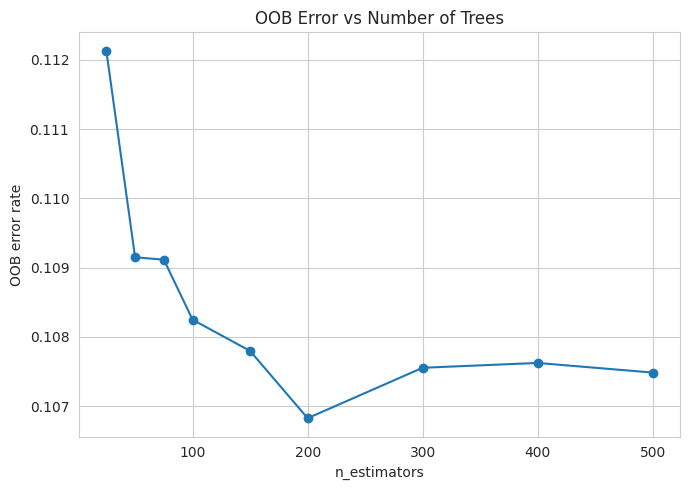

In [23]:
X_train_t = make_preprocessor().fit_transform(X_train)

n_estimators_range = [25,50,75,100,150,200,300,400,500]
oob_errors = []
for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42,
                                 class_weight='balanced', n_jobs=-1)
    rf.fit(X_train_t, y_train)
    oob_errors.append(1 - rf.oob_score_)
    print(f"n_estimators={n:4d}  OOB error={1-rf.oob_score_:.4f}")

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(n_estimators_range, oob_errors, marker='o')
ax.set_xlabel('n_estimators'); ax.set_ylabel('OOB error rate')
ax.set_title('OOB Error vs Number of Trees'); ax.grid(True)
plt.tight_layout(); plt.show()


max_depth=5      OOB error=0.1751


max_depth=10     OOB error=0.1462


max_depth=15     OOB error=0.1208


max_depth=20     OOB error=0.1089


max_depth=25     OOB error=0.1082


max_depth=30     OOB error=0.1061


max_depth=None   OOB error=0.1076


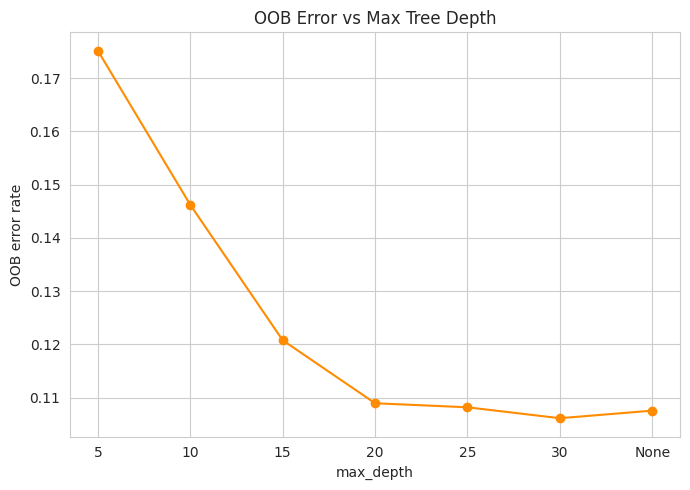

In [24]:
max_depth_range = [5,10,15,20,25,30,None]
oob_errors_depth, labels = [], []
for d in max_depth_range:
    rf = RandomForestClassifier(n_estimators=300, max_depth=d, oob_score=True,
                                 random_state=42, class_weight='balanced', n_jobs=-1)
    rf.fit(X_train_t, y_train)
    oob_errors_depth.append(1 - rf.oob_score_)
    labels.append(str(d))
    print(f"max_depth={str(d):5s}  OOB error={1-rf.oob_score_:.4f}")

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(labels, oob_errors_depth, marker='o', color='darkorange')
ax.set_xlabel('max_depth'); ax.set_ylabel('OOB error rate')
ax.set_title('OOB Error vs Max Tree Depth'); ax.grid(True)
plt.tight_layout(); plt.show()


**Decision:** `n_estimators=200` (error plateaus beyond this) and `max_depth=30` (lowest OOB error; unlimited depth slightly overfits).

## 9. Final Model Training

In [25]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_pipe = Pipeline([
    ('prep', make_preprocessor()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=30, oob_score=True,
                                    random_state=42, class_weight='balanced', n_jobs=-1))
])
final_pipe.fit(X_trainval, y_trainval)
print("Final model OOB score:", round(final_pipe.named_steps['clf'].oob_score_,4))


Final model OOB score: 0.8913


## 10. Model Evaluation

### 10.1 Core metrics on the test set

In [26]:
test_preds = final_pipe.predict(X_test)
test_proba = final_pipe.predict_proba(X_test)[:,1]

print("Accuracy:", round(accuracy_score(y_test, test_preds),4))
print("Precision (yes):", round(precision_score(y_test, test_preds),4))
print("Recall (yes):", round(recall_score(y_test, test_preds),4))
print("F1 (yes):", round(f1_score(y_test, test_preds),4))
print("ROC-AUC:", round(roc_auc_score(y_test, test_proba),4))
print("AUPRC:", round(average_precision_score(y_test, test_proba),4))
print()
print(classification_report(y_test, test_preds, target_names=['no','yes']))


Accuracy: 0.8915
Precision (yes): 0.5337
Recall (yes): 0.296
F1 (yes): 0.3808
ROC-AUC: 0.7936
AUPRC: 0.4343

              precision    recall  f1-score   support

          no       0.92      0.97      0.94      5481
         yes       0.53      0.30      0.38       696

    accuracy                           0.89      6177
   macro avg       0.72      0.63      0.66      6177
weighted avg       0.87      0.89      0.88      6177



### 10.2 Confusion Matrix

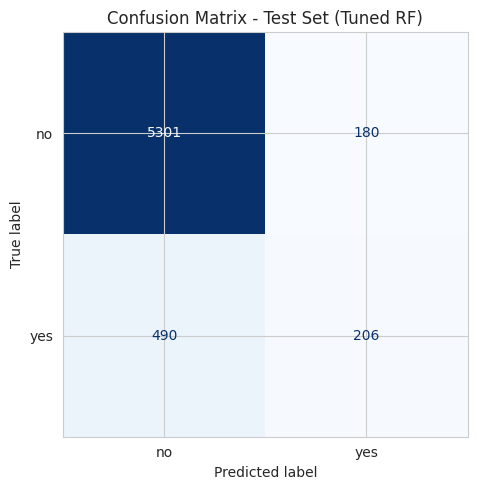

In [27]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay(cm, display_labels=['no','yes']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - Test Set (Tuned RF)')
plt.tight_layout(); plt.show()


### 10.3 Comparative Evaluation

All imbalance-handling strategies tested in this notebook are brought together here for a
direct, side-by-side comparison on the same validation set.

In [28]:
configs_results = []

# Default / balanced / balanced_subsample (re-run cleanly on the final split)
for name, cw in [('Default (no weighting)', None),
                  ("class_weight='balanced'", 'balanced'),
                  ("class_weight='balanced_subsample'", 'balanced_subsample')]:
    pipe = Pipeline([('prep', make_preprocessor()),
                      ('clf', RandomForestClassifier(n_estimators=200, max_depth=30, class_weight=cw,
                                                       oob_score=True, random_state=42, n_jobs=-1))])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_val)[:,1]
    preds = pipe.predict(X_val)
    configs_results.append({'Configuration': name,
        'Precision (yes)': round(precision_score(y_val,preds),4),
        'Recall (yes)': round(recall_score(y_val,preds),4),
        'F1 (yes)': round(f1_score(y_val,preds),4),
        'ROC-AUC': round(roc_auc_score(y_val,proba),4)})

# Balanced + tuned threshold
pipe_bal = Pipeline([('prep', make_preprocessor()),
                      ('clf', RandomForestClassifier(n_estimators=200, max_depth=30, class_weight='balanced',
                                                       oob_score=True, random_state=42, n_jobs=-1))])
pipe_bal.fit(X_train, y_train)
proba_val = pipe_bal.predict_proba(X_val)[:,1]
best_f1, best_t = 0, 0.5
for t in np.arange(0.1, 0.9, 0.02):
    f1 = f1_score(y_val, (proba_val >= t).astype(int))
    if f1 > best_f1: best_f1, best_t = f1, t
preds_best = (proba_val >= best_t).astype(int)
configs_results.append({'Configuration': f'Balanced + tuned threshold ({best_t:.2f})',
    'Precision (yes)': round(precision_score(y_val,preds_best),4),
    'Recall (yes)': round(recall_score(y_val,preds_best),4),
    'F1 (yes)': round(f1_score(y_val,preds_best),4),
    'ROC-AUC': round(roc_auc_score(y_val,proba_val),4)})

# SMOTE (reuse result computed in Section 3.5, recomputed here on the final split for consistency)
_prep_smote2 = make_preprocessor()
X_train_ft = _prep_smote2.fit_transform(X_train)
X_val_ft = _prep_smote2.transform(X_val)
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_ft, y_train)
rf_sm = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42, n_jobs=-1)
rf_sm.fit(X_train_sm, y_train_sm)
preds_sm = rf_sm.predict(X_val_ft); proba_sm = rf_sm.predict_proba(X_val_ft)[:,1]
configs_results.append({'Configuration': 'SMOTE (oversampled train)',
    'Precision (yes)': round(precision_score(y_val,preds_sm),4),
    'Recall (yes)': round(recall_score(y_val,preds_sm),4),
    'F1 (yes)': round(f1_score(y_val,preds_sm),4),
    'ROC-AUC': round(roc_auc_score(y_val,proba_sm),4)})

# IQR outlier removal (train only)
train_full = X_train.copy(); train_full['y_bin'] = y_train
mask_o = pd.Series(False, index=train_full.index)
for col in ['age','campaign','pdays_capped','previous','cons.conf.idx']:
    Q1,Q3 = train_full[col].quantile(0.25), train_full[col].quantile(0.75); IQRv = Q3-Q1
    mask_o |= (train_full[col] < Q1-1.5*IQRv) | (train_full[col] > Q3+1.5*IQRv)
train_clean = train_full[~mask_o]
pipe_iqr = Pipeline([('prep', make_preprocessor()),
                      ('clf', RandomForestClassifier(n_estimators=200, max_depth=30, class_weight='balanced',
                                                       random_state=42, n_jobs=-1))])
pipe_iqr.fit(train_clean[categorical_cols+numeric_cols], train_clean['y_bin'])
preds_iqr = pipe_iqr.predict(X_val); proba_iqr = pipe_iqr.predict_proba(X_val)[:,1]
configs_results.append({'Configuration': 'IQR outlier removal (train only)',
    'Precision (yes)': round(precision_score(y_val,preds_iqr),4),
    'Recall (yes)': round(recall_score(y_val,preds_iqr),4),
    'F1 (yes)': round(f1_score(y_val,preds_iqr),4),
    'ROC-AUC': round(roc_auc_score(y_val,proba_iqr),4)})

res_df = pd.DataFrame(configs_results)
res_df


,Configuration,Precision (yes),Recall (yes),F1 (yes),ROC-AUC
0,Default (no weighting),0.5408,0.2572,0.3486,0.7802
1,class_weight='balanced',0.5429,0.2543,0.3464,0.7791
2,class_weight='balanced_subsample',0.5500,0.2529,0.3465,0.7782
3,Balanced + tuned threshold (0.22),0.3954,0.5402,0.4566,0.7791
4,SMOTE (oversampled train),0.4797,0.3218,0.3852,0.7810
5,IQR outlier removal (train only),0.4700,0.1911,0.2717,0.7696


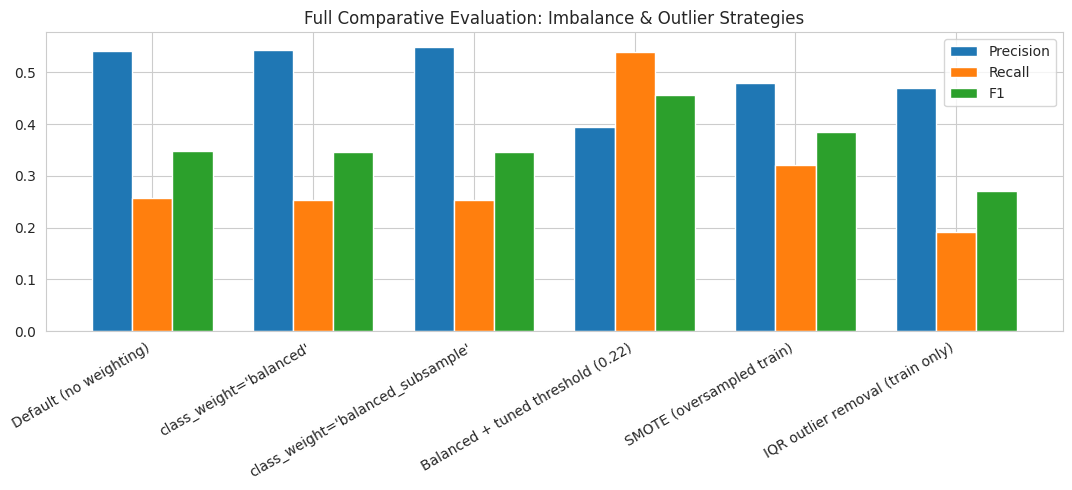

In [29]:
fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(res_df)); width=0.25
ax.bar(x-width, res_df['Precision (yes)'], width, label='Precision')
ax.bar(x, res_df['Recall (yes)'], width, label='Recall')
ax.bar(x+width, res_df['F1 (yes)'], width, label='F1')
ax.set_xticks(x); ax.set_xticklabels(res_df['Configuration'], rotation=30, ha='right')
ax.set_title('Full Comparative Evaluation: Imbalance & Outlier Strategies'); ax.legend()
plt.tight_layout(); plt.show()


**Summary of comparative evaluation:** class-weighting variants and SMOTE all improve recall
modestly over the default; SMOTE is the best of the "resampling-style" approaches (~0.32 recall).
IQR outlier removal is actively harmful. **Decision threshold tuning remains the single most
effective, cheapest intervention**, nearly doubling recall relative to the untouched baseline. The
final recommended configuration is therefore: full feature set, no outlier removal, `class_weight='balanced'`, with the decision threshold tuned to ~0.32 at deployment time.

## 11. Feature Importance

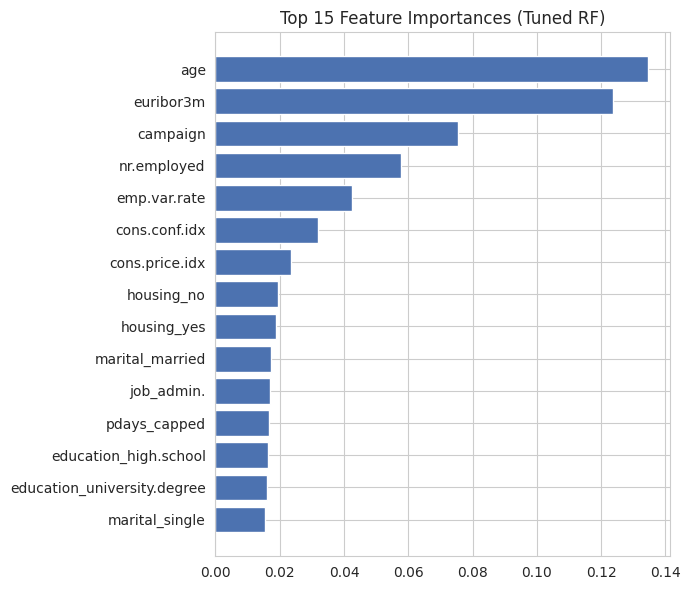

,feature,importance
53,age,0.134598
61,euribor3m,0.123596
54,campaign,0.075439
62,nr.employed,0.057857
58,emp.var.rate,0.042350
60,cons.conf.idx,0.031922
59,cons.price.idx,0.023598
27,housing_no,0.019371
29,housing_yes,0.018916
13,marital_married,0.017165


In [30]:
feat_names = (final_pipe.named_steps['prep']
              .named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
              + numeric_cols)
importances = final_pipe.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature':feat_names,'importance':importances}).sort_values('importance',ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7,6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#4C72B0')
ax.set_title('Top 15 Feature Importances (Tuned RF)')
plt.tight_layout(); plt.show()

imp_df.head(10)


## 12. Learning & Validation Charts

### 12.1 ROC Curve & Precision-Recall Curve

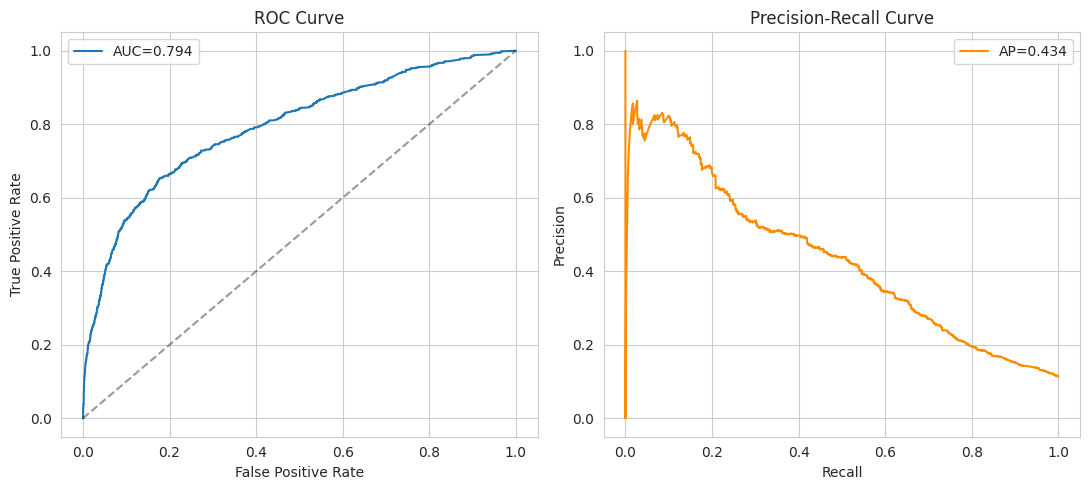

In [31]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
prec, rec, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1,2, figsize=(11,5))
axes[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test,test_proba):.3f}')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

axes[1].plot(rec, prec, label=f'AP={average_precision_score(y_test,test_proba):.3f}', color='darkorange')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()
plt.tight_layout(); plt.show()


### 12.2 OOB Score vs Trees
(Reproduced from Section 8 for convenience — see that section for the full sweep and discussion.)

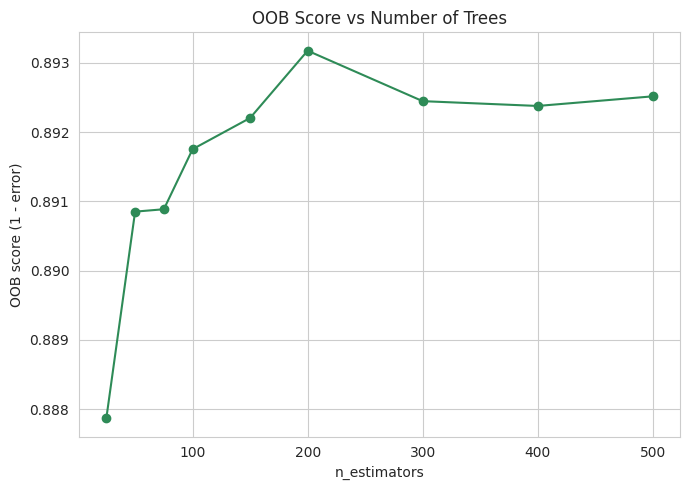

In [32]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(n_estimators_range, [1-e for e in oob_errors], marker='o', color='seagreen')
ax.set_xlabel('n_estimators'); ax.set_ylabel('OOB score (1 - error)')
ax.set_title('OOB Score vs Number of Trees'); ax.grid(True)
plt.tight_layout(); plt.show()


### 12.3 Train vs Test Accuracy (Overfitting Check)

n_estimators=10: train_acc=0.9814  test_acc=0.8896


n_estimators=25: train_acc=0.9922  test_acc=0.8886


n_estimators=50: train_acc=0.9949  test_acc=0.8920


n_estimators=100: train_acc=0.9958  test_acc=0.8914


n_estimators=200: train_acc=0.9958  test_acc=0.8927


n_estimators=300: train_acc=0.9958  test_acc=0.8925


n_estimators=500: train_acc=0.9958  test_acc=0.8917


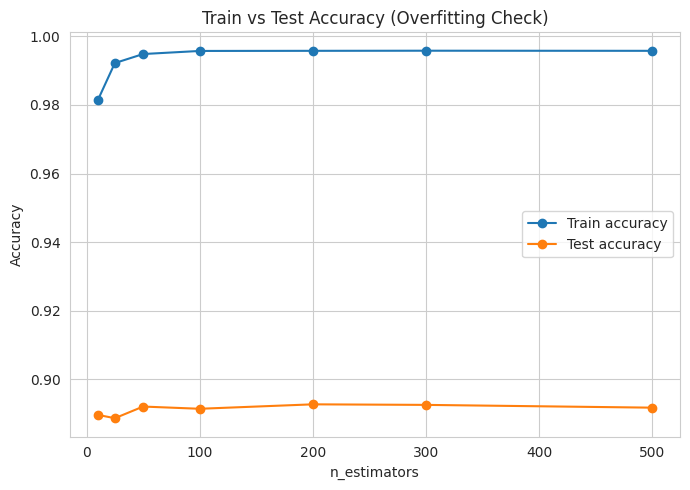

In [33]:
n_range = [10,25,50,100,200,300,500]
train_accs, test_accs = [], []
for n in n_range:
    m = Pipeline([('prep', make_preprocessor()),
                  ('clf', RandomForestClassifier(n_estimators=n, max_depth=30, class_weight='balanced',
                                                   random_state=42, n_jobs=-1))])
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))
    print(f"n_estimators={n}: train_acc={train_accs[-1]:.4f}  test_acc={test_accs[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(n_range, train_accs, marker='o', label='Train accuracy')
ax.plot(n_range, test_accs, marker='o', label='Test accuracy')
ax.set_xlabel('n_estimators'); ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy (Overfitting Check)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


**Finding:** training accuracy is very high (~99.5%) while test accuracy sits around 89-90% —
a substantial gap. This is expected behaviour for Random Forest, where individual trees can fit
their bootstrap sample almost perfectly; it is not the same as the model being unreliable, since the
**OOB score (Section 8-9) and the held-out test metrics (Section 10) are the trustworthy estimates of
real-world performance**, not the training accuracy. This gap is worth acknowledging explicitly as a
limitation of interpreting raw training accuracy for tree ensembles.

### 12.4 Feature Importance (repeated for chart completeness)
See Section 11 above for the chart and discussion.

### 12.5 Confusion Matrix Heatmap
See Section 10.2 above for the confusion matrix.

## 13. Bonus: Quantifying the `duration` Leakage Effect

Earlier, `duration` was excluded from all models above because it is only known after a call ends.
This final section trains a benchmark model *with* `duration` included, purely to quantify how much
of a difference the leaked feature makes — this model should never be used in production.

In [34]:
numeric_cols_with_duration = numeric_cols + ['duration']
X_train_d = df.loc[X_train.index, categorical_cols + numeric_cols_with_duration]
X_test_d  = df.loc[X_test.index,  categorical_cols + numeric_cols_with_duration]

preprocessor_d = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols_with_duration)
])
leak_pipe = Pipeline([('prep', preprocessor_d),
                       ('clf', RandomForestClassifier(n_estimators=200, max_depth=30, oob_score=True,
                                                        random_state=42, class_weight='balanced', n_jobs=-1))])
leak_pipe.fit(X_train_d, y_train)
test_preds_d = leak_pipe.predict(X_test_d)
test_proba_d = leak_pipe.predict_proba(X_test_d)[:,1]

comparison = pd.DataFrame([
    {'Model':'Primary (no duration)','Accuracy':round(accuracy_score(y_test,test_preds),4),
     'Recall (yes)':round(recall_score(y_test,test_preds),4),'F1 (yes)':round(f1_score(y_test,test_preds),4),
     'ROC-AUC':round(roc_auc_score(y_test,test_proba),4)},
    {'Model':'Benchmark (with duration)','Accuracy':round(accuracy_score(y_test,test_preds_d),4),
     'Recall (yes)':round(recall_score(y_test,test_preds_d),4),'F1 (yes)':round(f1_score(y_test,test_preds_d),4),
     'ROC-AUC':round(roc_auc_score(y_test,test_proba_d),4)},
])
comparison


,Model,Accuracy,Recall (yes),F1 (yes),ROC-AUC
0,Primary (no duration),0.8915,0.2960,0.3808,0.7936
1,Benchmark (with duration),0.9106,0.4009,0.5027,0.9462


**Finding:** including `duration` lifts ROC-AUC from ~0.79 to ~0.94 — but this reflects a feature unavailable at prediction time, not genuine model skill. This confirms the leakage decision made in Section 3 was correct, quantitatively rather than just by citing the dataset documentation.